In [ ]:
# Standard library imports
import importlib
import re
import json

# Local helper module
import utils
#importlib.reload(utils)

In [2]:
df = utils.load_and_prepare_data('coffee_sales.csv')
utils.print_html(df.sample(n=10), title="Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-10-18,10:40,card,ANON-0000-0000-0683,2.596,Americano,4,10,2024
2025-02-08,06:27,card,ANON-0000-0000-1163,2.596,Americano,1,2,2025
2024-10-26,06:49,card,ANON-0000-0000-0334,3.576,Cappuccino,4,10,2024
2024-03-18,11:27,card,ANON-0000-0000-0003,2.890,Americano,1,3,2024
2025-01-20,08:10,card,ANON-0000-0000-0276,3.086,Americano with Milk,1,1,2025
2024-12-23,17:06,card,ANON-0000-0000-1029,2.596,Cortado,4,12,2024
2025-03-04,13:02,card,ANON-0000-0000-1189,3.576,Cocoa,1,3,2025
2024-04-24,15:17,card,ANON-0000-0000-0134,3.772,Cappuccino,2,4,2024
2024-10-11,13:56,card,ANON-0000-0000-0714,3.576,Cappuccino,4,10,2024
2024-10-29,09:57,card,ANON-0000-0000-0832,3.576,Cappuccino,4,10,2024


In [3]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """Generate Python code to make a plot with matplotlib using tag-based wrapping."""

    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date   (datetime64 — already parsed; use df['date'].dt.year, df['date'].dt.month, etc.)
    - time   (string, HH:MM — do NOT concatenate or combine with the date column)
    - cash_type (string: 'card' or 'cash')
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (int, 1–4 — already computed, use directly)
    - month  (int, 1–12 — already computed, use directly)
    - year   (int, e.g. 2024 — already computed, use directly)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    8. CRITICAL: 'date' is datetime64 — never use string concatenation on it.
       Filter by year/quarter using the 'year' and 'quarter' integer columns.
    
    Return ONLY the code wrapped in <execute_python> tags.
    """

    response = utils.get_response(model, prompt)
    return response

In [4]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model="gpt-4o-mini", 
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")


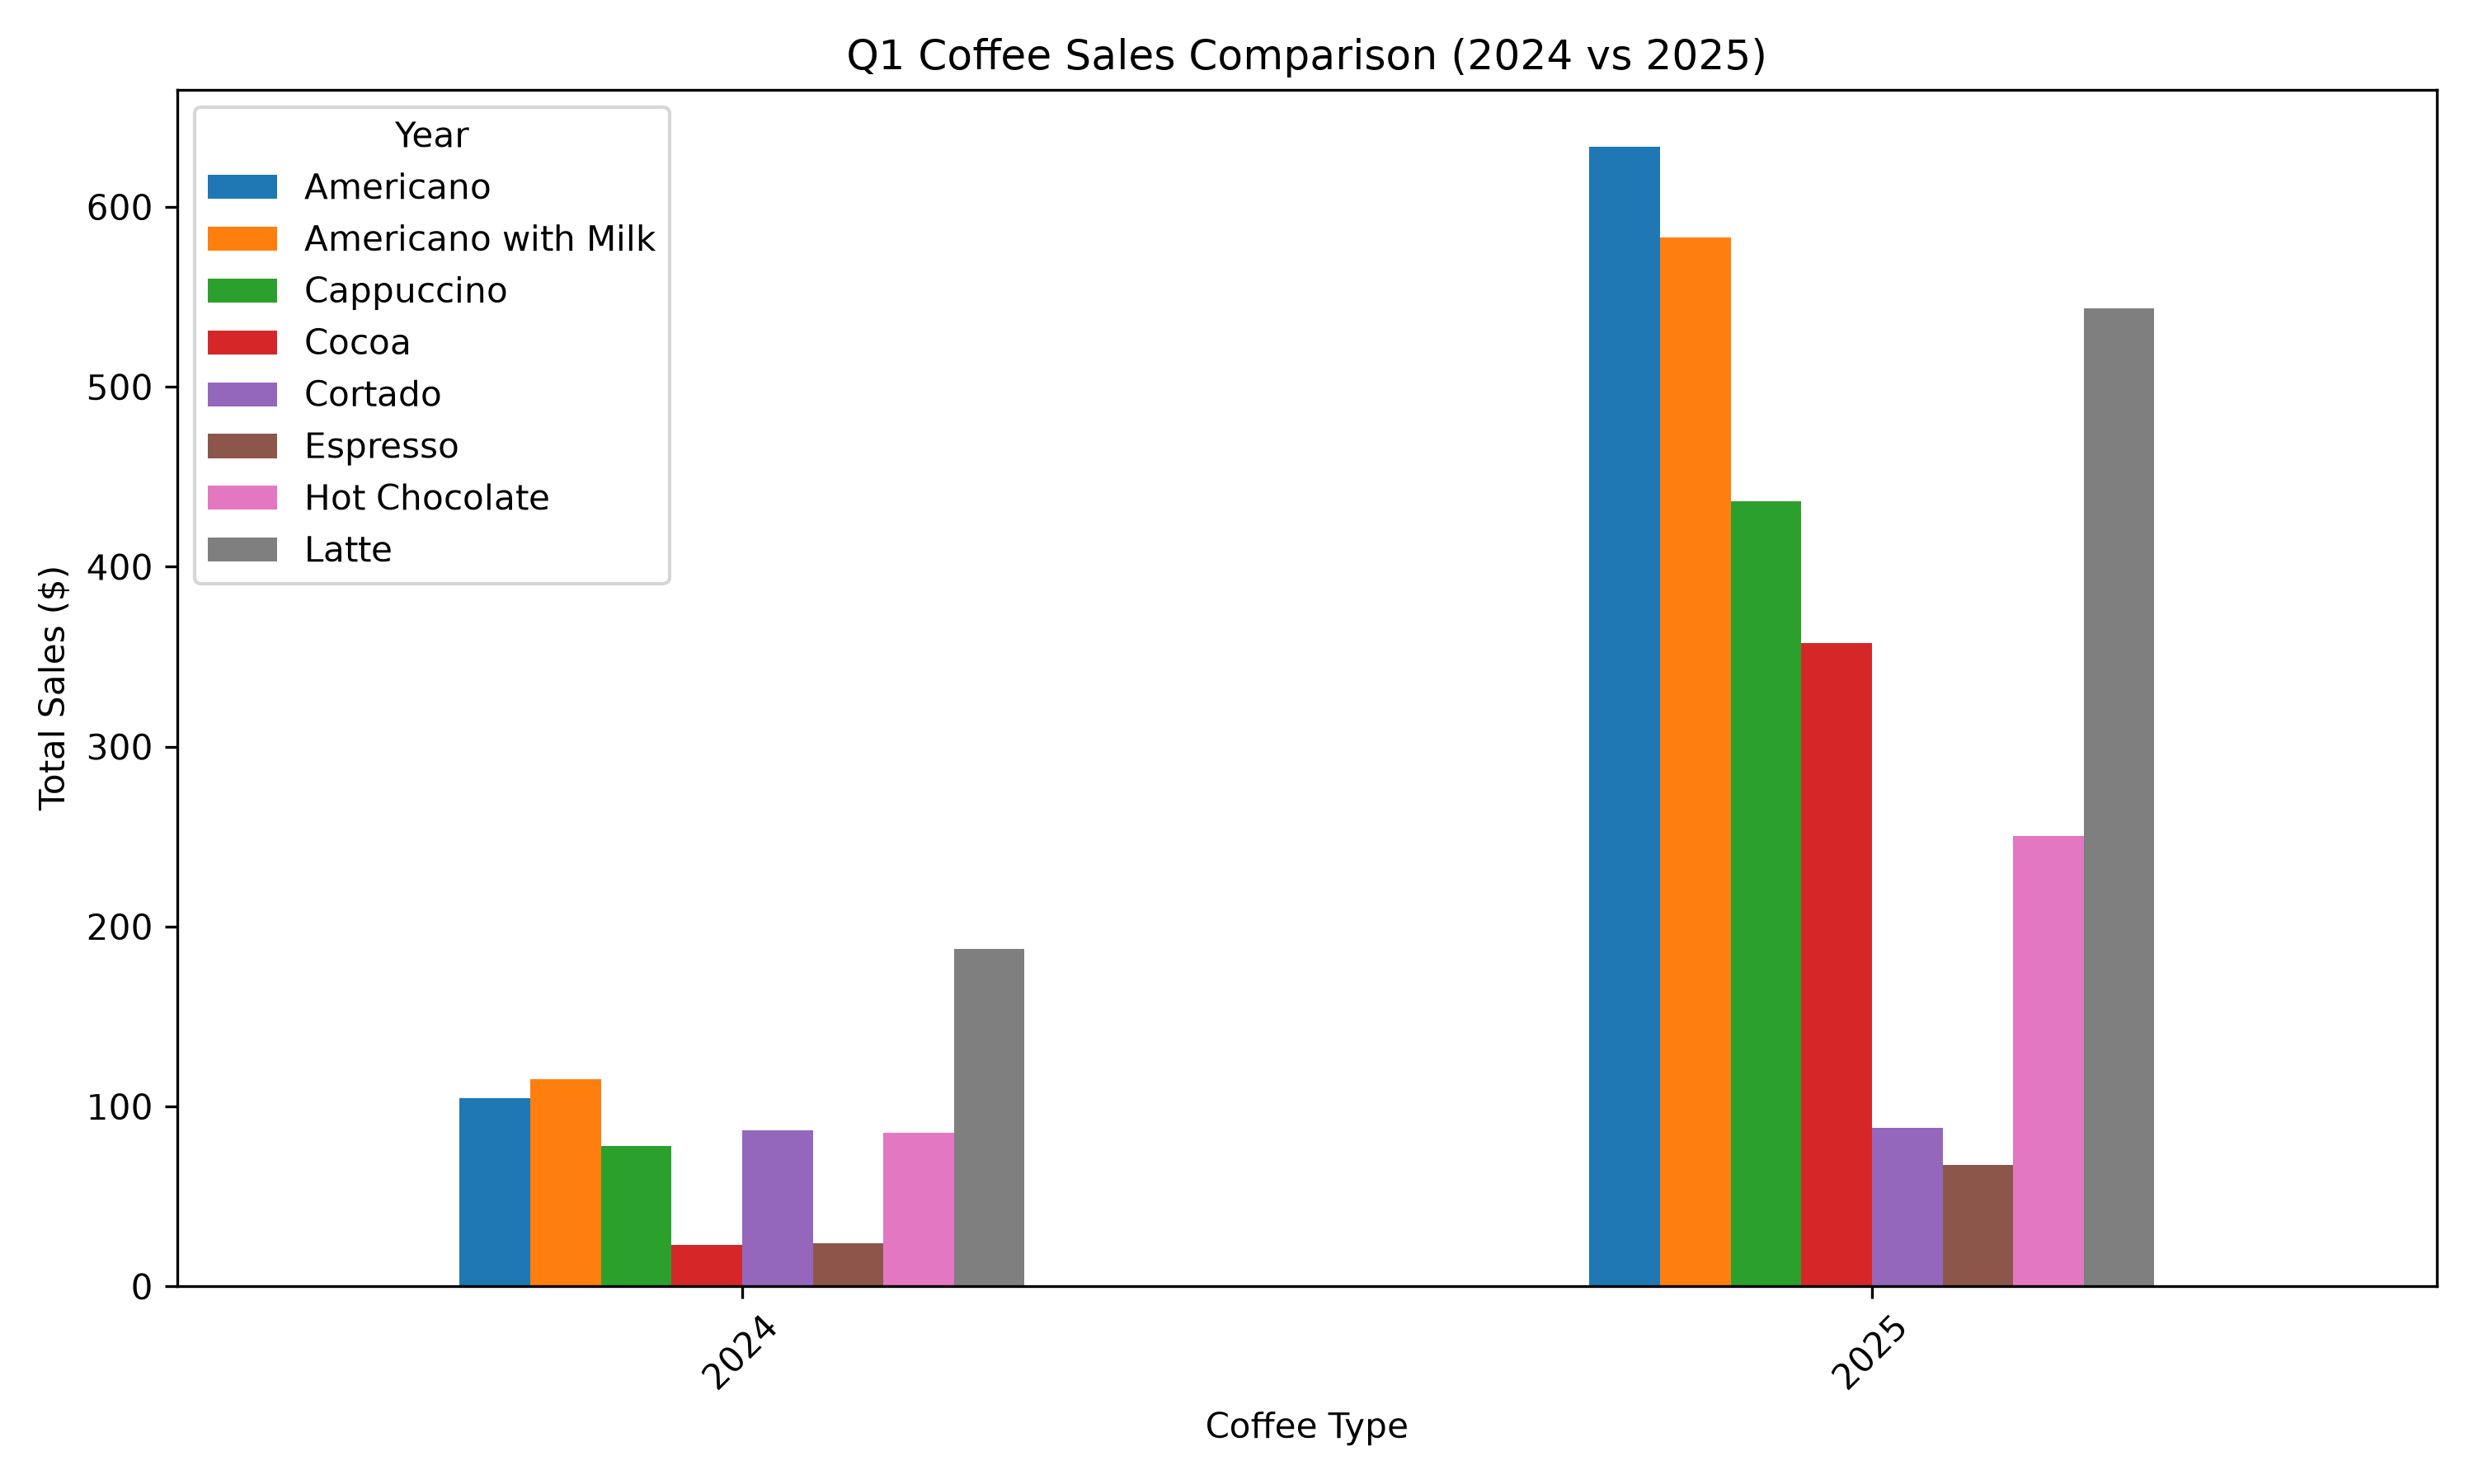

In [5]:
# Get code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1) 
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="Extracted Python code")
    exec_global = {"df": df}  # Provide the DataFrame in the global scope for exec
    exec(initial_code, exec_global)

# If code run successfully, the file chart_v1.png should have been generated
utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)
